# Gaussian Mixture Model - Instacart (extended)


Evaluación del número de clusters y ajuste final del modelo. El `k` recomendado se selecciona mediante el mayor coeficiente silhouette.


In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

from modeling_functions import (
    gmm_metrics,
    plot_clustering_metrics,
    analyze_clusters,
    fit_clustering_model,
    save_clustering_metrics,
)
import pandas as pd

## Carga y preparación de los datos


In [2]:
df_scaled = pd.read_csv("../../../scaled_data/instacart_scaled.csv")
df_original = pd.read_csv("../../../extended_datasets/instacart_model_extended.csv")

# Conserva en el escalado solo las variables incluidas en esta versión del dataset.
columnas_modelo = [col for col in df_original.columns if col in df_scaled.columns]
df_scaled_modelo = df_scaled[columnas_modelo].copy()
X = df_scaled_modelo.drop(columns=["user_id"], errors="ignore")

print(f"Observaciones: {X.shape[0]:,}")
print(f"Variables de clustering: {X.shape[1]}")
display(X.head())

Observaciones: 206,209
Variables de clustering: 11


,recency,frequency,avg_basket_size,std_basket_size,avg_days_between_orders,std_days_between_orders,unique_products,unique_aisles,unique_departments,reorder_ratio,product_variety_ratio
0,-0.286895,-0.070348,-0.578158,-1.227829,0.699419,0.241265,-0.990167,-1.002478,-1.009504,1.238152,-1.238152
1,1.212334,0.316791,0.820566,0.729024,0.322297,0.371165,0.903750,0.454433,0.572875,0.210583,-0.210583
2,-0.568000,0.138171,-0.236083,-0.814629,-0.427875,-1.032762,-0.338142,-0.660110,-0.482044,0.908586,-0.908586
3,1.212334,-0.826933,-1.313020,-0.833881,0.134288,0.741993,-1.050748,-0.825157,-0.482044,-1.775655,1.775655
4,-1.036509,-1.054508,0.139108,-0.260001,-0.769372,-0.728977,-0.728409,-0.660110,-0.482044,-0.253936,0.253936


## Evaluación del número de clusters


In [3]:
resultados_gmm = gmm_metrics(X)
display(resultados_gmm)

,k,silhouette,calinski_harabasz,davies_bouldin,bic,aic,tiempo_segundos
0,2,0.272159,96986.031560,1.361796,5.705837e+06,5.705377e+06,2.065844
1,3,0.230769,82745.902356,1.501234,5.299103e+06,5.298407e+06,0.492870
2,4,0.212833,71455.264910,1.376142,5.133232e+06,5.132301e+06,0.543102
3,5,0.181948,62529.393629,1.521328,4.897012e+06,4.895845e+06,0.960805
4,6,0.190950,58354.102915,1.380305,4.803006e+06,4.801604e+06,1.493904
5,7,0.171891,52884.973954,1.521062,4.709827e+06,4.708189e+06,3.097898
6,8,0.159274,49370.435833,1.534693,4.596701e+06,4.594828e+06,3.296039
7,9,0.153801,45832.606203,1.576082,4.550205e+06,4.548096e+06,1.871847
8,10,0.112863,36256.837201,1.706418,4.109859e+06,4.107515e+06,4.291924


In [ ]:
tabla_metricas = save_clustering_metrics(
    resultados_gmm,
    model_name="gmm",
    dataset_name="instacart",
    dataset_version="extended",
)

print("Métricas consolidadas en ../../../results/clustering_metrics.csv")
display(tabla_metricas)

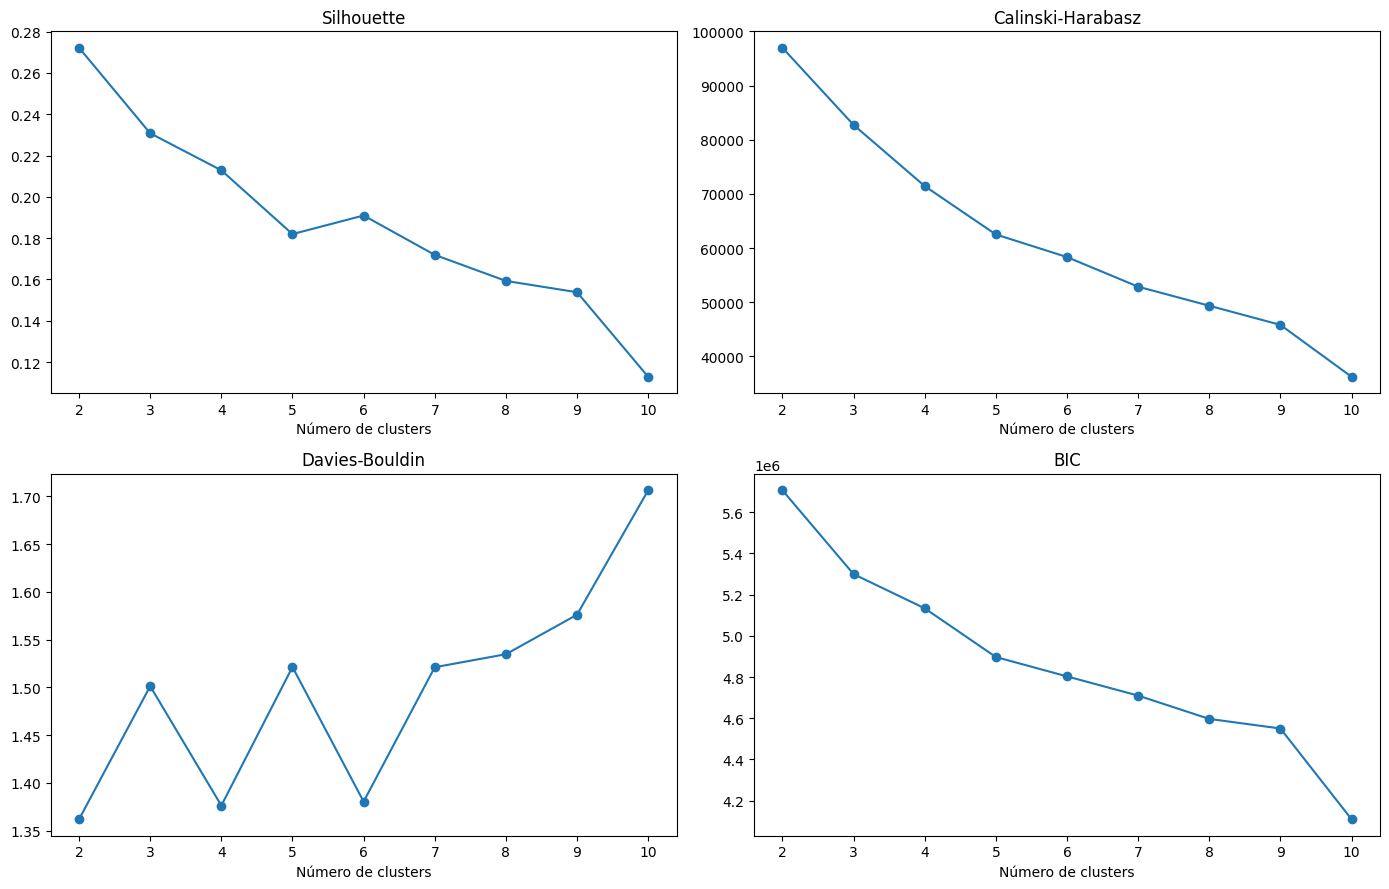

In [4]:
plot_clustering_metrics(
    resultados_gmm,
    fourth_metric="bic",
    fourth_title="BIC",
)

## Ajuste final y perfil de los clusters


In [ ]:
modelo, labels = fit_clustering_model(
    model_name="gmm",
    k=2,
    X=X,
)

cluster_sizes, porcentajes, perfil_clusters, df_clusterizado = analyze_clusters(
    labels=labels,
    df_scaled=df_scaled_modelo,
    df_original=df_original,
    id_col="user_id",
)

print("Tamaño de los clusters:")
display(cluster_sizes)
print("Porcentaje de clientes:")
display(porcentajes)
print("Perfil medio de los clusters:")
display(perfil_clusters)

Tamaño de los clusters:


cluster
0     89636
1    116573
Name: count, dtype: int64

Porcentaje de clientes:


cluster
0    43.47
1    56.53
Name: proportion, dtype: float64

Perfil medio de los clusters:


,recency,frequency,avg_basket_size,std_basket_size,avg_days_between_orders,std_days_between_orders,unique_products,unique_aisles,unique_departments,reorder_ratio,product_variety_ratio
cluster,,,,,,,,,,,
0,12.894,26.266,12.647,5.430,10.765,7.474,109.244,41.629,13.829,0.554,0.446
1,20.267,7.381,7.879,3.371,15.477,11.020,30.159,17.138,8.520,0.339,0.661


- Cluster 0 - Clientes frecuentes y recurrentes (43,47%): compran recientemente y con alta frecuencia, realizan cestas grandes y acceden a una variedad muy amplia. La elevada recompra confirma hábitos consolidados.
- Cluster 1 - Clientes ocasionales y exploratorios (56,53%): presentan mayor recencia, pocos pedidos y cestas pequeñas. Compran menos productos y categorías, con menor recompra y mayor variedad relativa.